In [ ]:
##K-Means: Elbow + Silhouette analysis (k=6–10); final k selected by Davies-Bouldin index##

In [31]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (

    silhouette_score,

    davies_bouldin_score
)

import matplotlib.pyplot as plt

import seaborn as sns

In [32]:

data = pd.read_csv(
    r"C:\Users\sabsm\Documents\Amdex DS Group Project Materials\cleaned_online_retail.csv\cleaned_online_retail.csv",
    low_memory=False
)

In [33]:
def categorize_product(desc):

    desc = str(desc).lower()

    # Storage & Bags
    if (
        "bag" in desc or
        "basket" in desc or
        "box" in desc
    ):
        return "Storage & Bags"

    # Kitchen
    elif (
        "glass" in desc or
        "jar" in desc or
        "plate" in desc or
        "bowl" in desc or
        "kitchen" in desc or
        "mug" in desc or
        "cup" in desc
    ):
        return "Kitchen"

    # Home Decor
    elif (
        "heart" in desc or
        "holder" in desc or
        "candle" in desc or
        "decor" in desc or
        "vase" in desc
    ):
        return "Home Decor"

    # Kids
    elif (
        "toy" in desc or
        "child" in desc or
        "kids" in desc or
        "doll" in desc
    ):
        return "Kids"

    # Seasonal
    elif (
        "christmas" in desc or
        "xmas" in desc or
        "holiday" in desc
    ):
        return "Seasonal"

    # Stationery
    elif (
        "pen" in desc or
        "paper" in desc or
        "card" in desc or
        "notebook" in desc
    ):
        return "Stationery"

    # Lighting
    elif (
        "light" in desc or
        "lamp" in desc
    ):
        return "Lighting"

    # Textile
    elif (
        "fabric" in desc or
        "blanket" in desc or
        "cushion" in desc
    ):
        return "Textile"

    # Photo & Frames
    elif (
        "frame" in desc or
        "photo" in desc
    ):
        return "Photo & Frames"

    # Clocks
    elif "clock" in desc:
        return "Clocks"

    # Garden
    elif (
        "flower" in desc or
        "garden" in desc
    ):
        return "Garden"

    # Furniture & Decor
    elif (
        "wooden" in desc or
        "metal" in desc
    ):
        return "Furniture & Decor"

    # Default
    else:
        return "Other"

In [34]:
data["Category"] = data["Description"].apply(
    categorize_product
)

In [35]:
print(data["Category"].value_counts())

Category
Other                383526
Storage & Bags       153484
Home Decor           134104
Kitchen               93787
Stationery            69058
Furniture & Decor     41245
Seasonal              32518
Kids                  31991
Garden                19732
Lighting              17389
Photo & Frames        13143
Clocks                 9606
Textile                8331
Name: count, dtype: int64


In [36]:
print(data.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'CustomerID', 'Country', 'Revenue', 'Category'],
      dtype='object')


In [37]:
data["InvoiceDate"] = pd.to_datetime(
    data["InvoiceDate"]
)

In [38]:
data = data.dropna(
    subset=["CustomerID"]
)

In [39]:
data["Category"] = data["Description"].apply(
    categorize_product
)

In [40]:
reference_date = (

    data["InvoiceDate"].max()

    + pd.Timedelta(days=1)
)

In [41]:
rfm = data.groupby(

    ["CustomerID", "Category"]

).agg({

    "InvoiceDate":
        lambda x:
        (reference_date - x.max()).days,

    "InvoiceNo": "nunique",

    "Revenue": "sum"

})

In [42]:
rfm.columns = [

    "Recency",

    "Frequency",

    "Monetary"
]

In [43]:
rfm = rfm.reset_index()

In [44]:
rfm_encoded = pd.get_dummies(

    rfm,

    columns=["Category"]
)

In [45]:
features = rfm_encoded.drop(

    columns=["CustomerID"]
)

In [46]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    features
)

In [47]:
k_values = range(6,11)

wcss = []

silhouette_scores = []

db_scores = []

for k in k_values:

    kmeans = KMeans(

        n_clusters=k,

        n_init=10,

        random_state=42
    )

    labels = kmeans.fit_predict(
        scaled_features
    )

    # WCSS
    wcss.append(
        kmeans.inertia_
    )

    # Silhouette
    silhouette_scores.append(

        silhouette_score(
            scaled_features,
            labels
        )
    )

    # Davies-Bouldin
    db_scores.append(

        davies_bouldin_score(
            scaled_features,
            labels
        )
    )

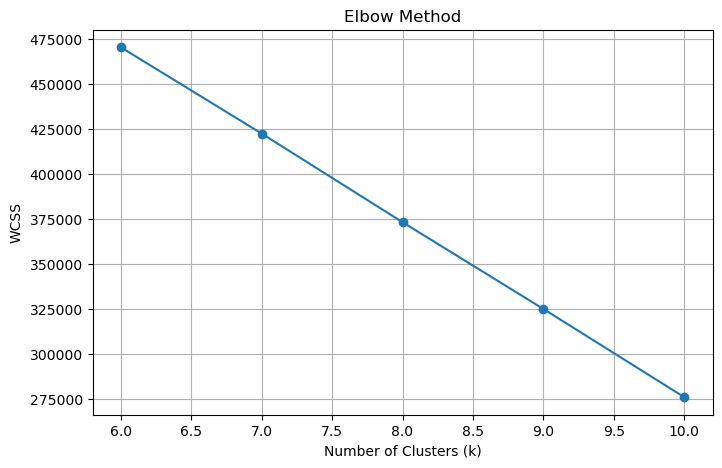

In [48]:
plt.figure(figsize=(8,5))

plt.plot(

    k_values,

    wcss,

    marker='o'
)

plt.title(
    "Elbow Method"
)

plt.xlabel(
    "Number of Clusters (k)"
)

plt.ylabel(
    "WCSS"
)

plt.grid(True)

plt.show()

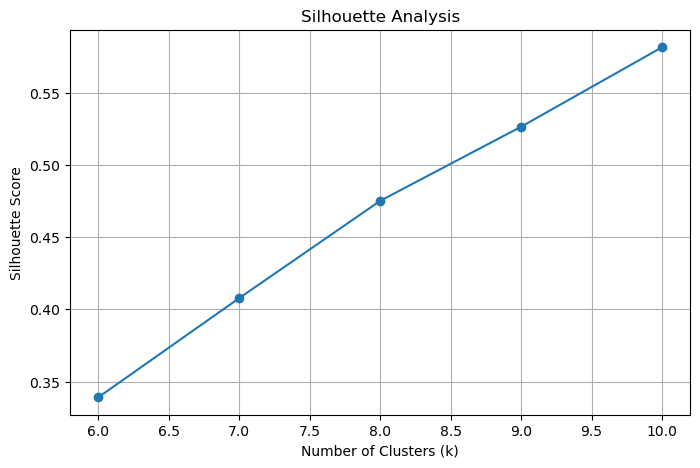

In [49]:
plt.figure(figsize=(8,5))

plt.plot(

    k_values,

    silhouette_scores,

    marker='o'
)

plt.title(
    "Silhouette Analysis"
)

plt.xlabel(
    "Number of Clusters (k)"
)

plt.ylabel(
    "Silhouette Score"
)

plt.grid(True)

plt.show()

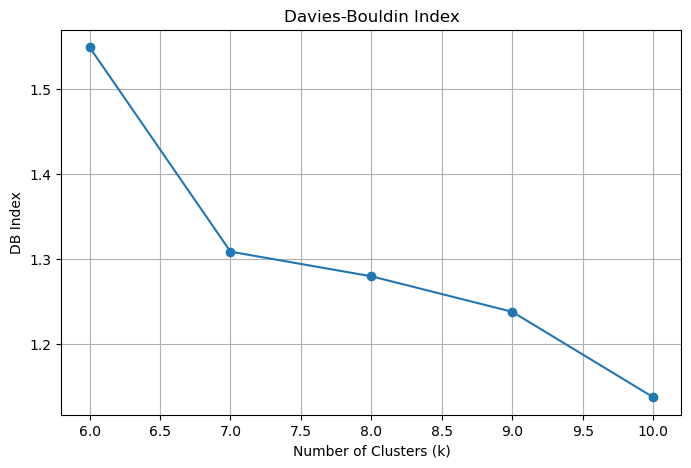

In [50]:
plt.figure(figsize=(8,5))

plt.plot(

    k_values,

    db_scores,

    marker='o'
)

plt.title(
    "Davies-Bouldin Index"
)

plt.xlabel(
    "Number of Clusters (k)"
)

plt.ylabel(
    "DB Index"
)

plt.grid(True)

plt.show()

In [51]:
best_k = k_values[np.argmin(db_scores)]

print(
    "Best K based on Davies-Bouldin Index:",
    best_k
)

Best K based on Davies-Bouldin Index: 10


In [52]:
final_kmeans = KMeans(

    n_clusters=best_k,

    n_init=10,

    random_state=42
)

rfm_encoded["Cluster"] = final_kmeans.fit_predict(

    scaled_features
)

In [53]:
cluster_summary = rfm_encoded.groupby(

    "Cluster"

)[

    ["Recency",
     "Frequency",
     "Monetary"]

].mean()

print(cluster_summary)

            Recency  Frequency     Monetary
Cluster                                    
0        203.934469   6.025826  1324.996402
1        223.334754   4.515235   332.420641
2        230.495600   3.715331   261.696633
3        182.155722   2.547842   160.050313
4        230.282003   3.888049   178.544927
5        221.337451   4.891909   537.029246
6        271.945264   2.842251    94.937297
7        255.237515   3.540941   194.866832
8        318.383445   2.134510    76.981611
9        243.809180   3.296133   146.296797


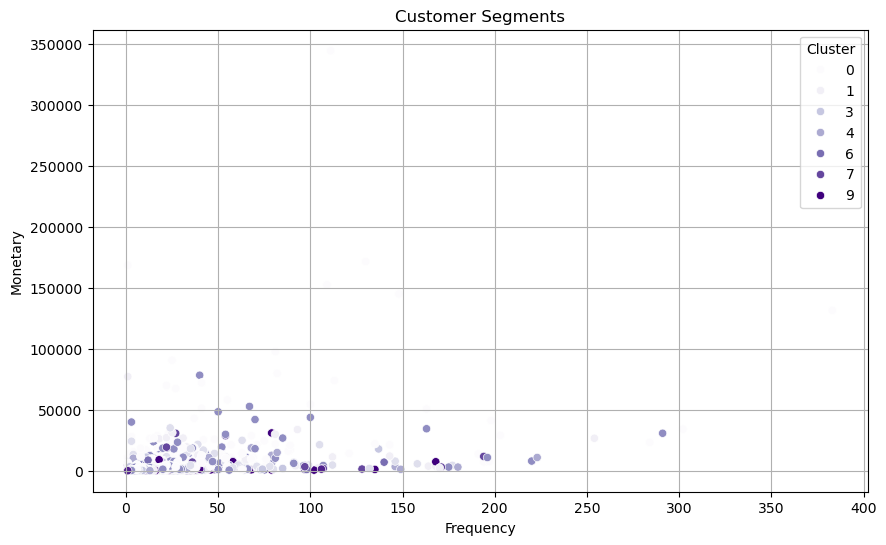

In [54]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    x="Frequency",

    y="Monetary",

    hue="Cluster",

    data=rfm_encoded,

    palette="Purples"
)

plt.title(
    "Customer Segments"
)

plt.grid(True)

plt.show()

In [ ]:
##DBSCAN: auto eps via k-distance graph; identify outlier / ultra-VIP customer clusters##

In [55]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN

from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt

import seaborn as sns

In [56]:

data = pd.read_csv(
    r"C:\Users\sabsm\Documents\Amdex DS Group Project Materials\cleaned_online_retail.csv\cleaned_online_retail.csv",
    low_memory=False
)

In [57]:
def categorize_product(desc):

    desc = str(desc).lower()

    # Storage & Bags
    if (
        "bag" in desc or
        "basket" in desc or
        "box" in desc
    ):
        return "Storage & Bags"

    # Kitchen
    elif (
        "glass" in desc or
        "jar" in desc or
        "plate" in desc or
        "bowl" in desc or
        "kitchen" in desc or
        "mug" in desc or
        "cup" in desc
    ):
        return "Kitchen"

    # Home Decor
    elif (
        "heart" in desc or
        "holder" in desc or
        "candle" in desc or
        "decor" in desc or
        "vase" in desc
    ):
        return "Home Decor"

    # Kids
    elif (
        "toy" in desc or
        "child" in desc or
        "kids" in desc or
        "doll" in desc
    ):
        return "Kids"

    # Seasonal
    elif (
        "christmas" in desc or
        "xmas" in desc or
        "holiday" in desc
    ):
        return "Seasonal"

    # Stationery
    elif (
        "pen" in desc or
        "paper" in desc or
        "card" in desc or
        "notebook" in desc
    ):
        return "Stationery"

    # Lighting
    elif (
        "light" in desc or
        "lamp" in desc
    ):
        return "Lighting"

    # Textile
    elif (
        "fabric" in desc or
        "blanket" in desc or
        "cushion" in desc
    ):
        return "Textile"

    # Photo & Frames
    elif (
        "frame" in desc or
        "photo" in desc
    ):
        return "Photo & Frames"

    # Clocks
    elif "clock" in desc:
        return "Clocks"

    # Garden
    elif (
        "flower" in desc or
        "garden" in desc
    ):
        return "Garden"

    # Furniture & Decor
    elif (
        "wooden" in desc or
        "metal" in desc
    ):
        return "Furniture & Decor"

    # Default
    else:
        return "Other"

In [58]:
data["Category"] = data["Description"].apply(
    categorize_product
)

In [59]:
print(data["Category"].value_counts())

Category
Other                383526
Storage & Bags       153484
Home Decor           134104
Kitchen               93787
Stationery            69058
Furniture & Decor     41245
Seasonal              32518
Kids                  31991
Garden                19732
Lighting              17389
Photo & Frames        13143
Clocks                 9606
Textile                8331
Name: count, dtype: int64


In [60]:
print(data.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'CustomerID', 'Country', 'Revenue', 'Category'],
      dtype='object')


In [61]:
data["InvoiceDate"] = pd.to_datetime(
    data["InvoiceDate"]
)

In [62]:
data = data.dropna(
    subset=["CustomerID"]
)

In [63]:
data["Category"] = data["Description"].apply(
    categorize_product
)

In [64]:
reference_date = (

    data["InvoiceDate"].max()

    + pd.Timedelta(days=1)
)

In [65]:
rfm = data.groupby(

    ["CustomerID", "Category"]

).agg({

    "InvoiceDate":
        lambda x:
        (reference_date - x.max()).days,

    "InvoiceNo": "nunique",

    "Revenue": "sum"

})

In [66]:
rfm.columns = [

    "Recency",

    "Frequency",

    "Monetary"
]

In [67]:
rfm = rfm.reset_index()

In [68]:
rfm_encoded = pd.get_dummies(

    rfm,

    columns=["Category"]
)

In [69]:
features = rfm_encoded.drop(

    columns=["CustomerID"]
)

In [70]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    features
)

In [71]:
neighbors = NearestNeighbors(
    n_neighbors=5
)

neighbors_fit = neighbors.fit(
    scaled_features
)

distances, indices = neighbors_fit.kneighbors(
    scaled_features
)

In [72]:
distances = np.sort(
    distances[:,4]
)

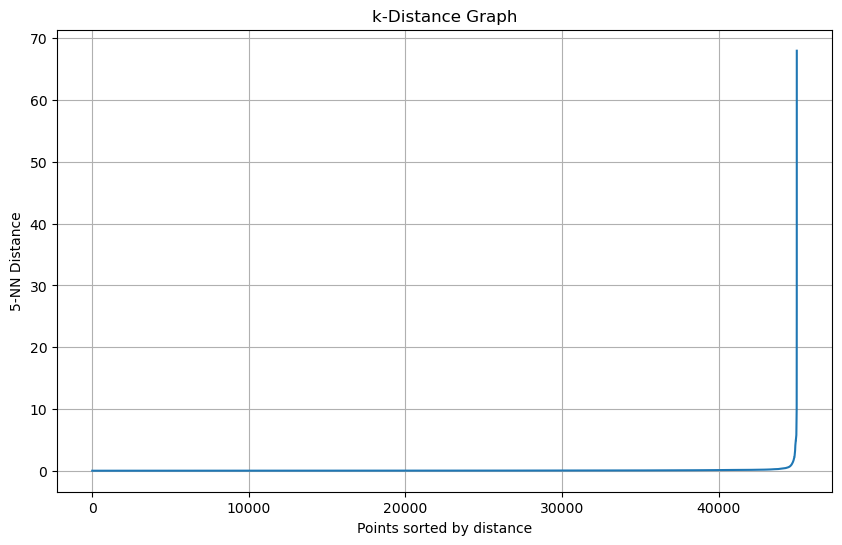

In [75]:
plt.figure(figsize=(10,6))

plt.plot(distances)

plt.title(
    "k-Distance Graph"
)

plt.xlabel(
    "Points sorted by distance"
)

plt.ylabel(
    "5-NN Distance"
)

plt.grid(True)

plt.show()

In [76]:
1.3

1.3

In [77]:
eps = 1.3

In [78]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(

    eps=eps,

    min_samples=5
)

rfm_encoded["Cluster"] = dbscan.fit_predict(

    scaled_features
)

In [79]:
print(

    rfm_encoded["Cluster"]

    .value_counts()
)

Cluster
 1     5630
 6     4969
 11    4822
 7     4668
 10    4218
 4     3431
 5     3244
 2     3193
 0     3171
 8     2595
 9     1963
 12    1635
 3     1231
-1      211
 14       5
 13       3
Name: count, dtype: int64


In [80]:
outliers = rfm_encoded[

    rfm_encoded["Cluster"] == -1
]

print(outliers.head())

     CustomerID  Recency  Frequency  Monetary  Category_Clocks  \
1       12346.0      326          1  77183.60            False   
489     12415.0       66         13  12529.25            False   
490     12415.0       25         14  11083.21            False   
492     12415.0       25         22  69882.42            False   
496     12415.0       25         15  23714.39            False   

     Category_Furniture & Decor  Category_Garden  Category_Home Decor  \
1                         False            False                False   
489                       False            False                False   
490                       False            False                False   
492                       False            False                False   
496                       False            False                False   

     Category_Kids  Category_Kitchen  Category_Lighting  Category_Other  \
1            False              True              False           False   
489           

In [81]:
vip_customers = rfm_encoded[

    (rfm_encoded["Monetary"] >
     rfm_encoded["Monetary"].quantile(0.99))

    &

    (rfm_encoded["Frequency"] >
     rfm_encoded["Frequency"].quantile(0.95))
]

print(vip_customers.head())

     CustomerID  Recency  Frequency  Monetary  Category_Clocks  \
490     12415.0       25         14  11083.21            False   
492     12415.0       25         22  69882.42            False   
496     12415.0       25         15  23714.39            False   
690     12437.0        2         39   5518.32            False   
929     12471.0        2         75  24524.60            False   

     Category_Furniture & Decor  Category_Garden  Category_Home Decor  \
490                       False            False                False   
492                       False            False                False   
496                       False            False                False   
690                       False            False                False   
929                       False            False                False   

     Category_Kids  Category_Kitchen  Category_Lighting  Category_Other  \
490          False              True              False           False   
492          F

In [82]:
cluster_summary = rfm_encoded.groupby(

    "Cluster"

)[

    ["Recency",
     "Frequency",
     "Monetary"]

].mean()

print(cluster_summary)

            Recency  Frequency      Monetary
Cluster                                     
-1        86.886256  76.018957  21716.473318
 0       244.397982   3.066856    124.200013
 1       205.201421   5.175311    850.930290
 2       182.416223   2.450987    147.288024
 3       218.178716   2.495532    132.855451
 4       256.067619   3.220052    161.053562
 5       272.544081   2.697287     83.101418
 6       216.399074   4.400080    332.108712
 7       224.012853   4.136675    245.476489
 8       254.233141   2.797688    155.842501
 9       245.376974   2.804890    128.001594
 10      230.832385   3.574680    149.318898
 11      222.190585   4.397968    393.183183
 12      319.197554   1.982875     56.017839
 13       14.000000  43.666667   1133.140000
 14        8.800000  40.000000  15901.054000


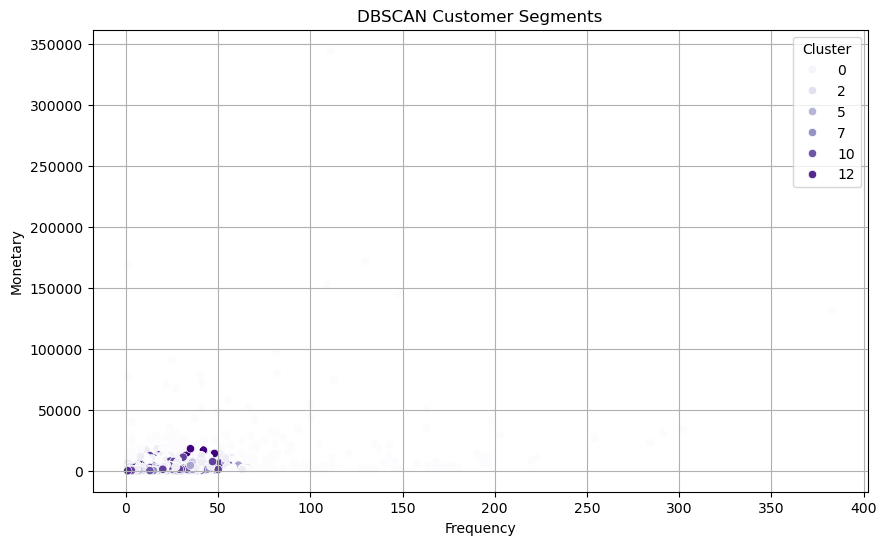

In [83]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    x="Frequency",

    y="Monetary",

    hue="Cluster",

    data=rfm_encoded,

    palette="Purples"
)

plt.title(
    "DBSCAN Customer Segments"
)

plt.grid(True)

plt.show()

In [ ]:
##Gaussian Mixture Models: probabilistic segment membership for borderline customers##

In [84]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

import seaborn as sns

In [85]:
data = pd.read_csv(
    r"C:\Users\sabsm\Documents\Amdex DS Group Project Materials\cleaned_online_retail.csv\cleaned_online_retail.csv",
    low_memory=False
)

In [86]:
def categorize_product(desc):

    desc = str(desc).lower()

    # Storage & Bags
    if (
        "bag" in desc or
        "basket" in desc or
        "box" in desc
    ):
        return "Storage & Bags"

    # Kitchen
    elif (
        "glass" in desc or
        "jar" in desc or
        "plate" in desc or
        "bowl" in desc or
        "kitchen" in desc or
        "mug" in desc or
        "cup" in desc
    ):
        return "Kitchen"

    # Home Decor
    elif (
        "heart" in desc or
        "holder" in desc or
        "candle" in desc or
        "decor" in desc or
        "vase" in desc
    ):
        return "Home Decor"

    # Kids
    elif (
        "toy" in desc or
        "child" in desc or
        "kids" in desc or
        "doll" in desc
    ):
        return "Kids"

    # Seasonal
    elif (
        "christmas" in desc or
        "xmas" in desc or
        "holiday" in desc
    ):
        return "Seasonal"

    # Stationery
    elif (
        "pen" in desc or
        "paper" in desc or
        "card" in desc or
        "notebook" in desc
    ):
        return "Stationery"

    # Lighting
    elif (
        "light" in desc or
        "lamp" in desc
    ):
        return "Lighting"

    # Textile
    elif (
        "fabric" in desc or
        "blanket" in desc or
        "cushion" in desc
    ):
        return "Textile"

    # Photo & Frames
    elif (
        "frame" in desc or
        "photo" in desc
    ):
        return "Photo & Frames"

    # Clocks
    elif "clock" in desc:
        return "Clocks"

    # Garden
    elif (
        "flower" in desc or
        "garden" in desc
    ):
        return "Garden"

    # Furniture & Decor
    elif (
        "wooden" in desc or
        "metal" in desc
    ):
        return "Furniture & Decor"

    # Default
    else:
        return "Other"

In [87]:
data["Category"] = data["Description"].apply(
    categorize_product
)

In [88]:
print(data["Category"].value_counts())

Category
Other                383526
Storage & Bags       153484
Home Decor           134104
Kitchen               93787
Stationery            69058
Furniture & Decor     41245
Seasonal              32518
Kids                  31991
Garden                19732
Lighting              17389
Photo & Frames        13143
Clocks                 9606
Textile                8331
Name: count, dtype: int64


In [89]:
print(data.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'CustomerID', 'Country', 'Revenue', 'Category'],
      dtype='object')


In [90]:
data["InvoiceDate"] = pd.to_datetime(
    data["InvoiceDate"]
)

In [91]:
data = data.dropna(
    subset=["CustomerID"]
)

In [92]:
data["Category"] = data["Description"].apply(
    categorize_product
)

In [93]:
reference_date = (

    data["InvoiceDate"].max()

    + pd.Timedelta(days=1)
)

In [94]:
rfm = data.groupby(

    ["CustomerID", "Category"]

).agg({

    "InvoiceDate":
        lambda x:
        (reference_date - x.max()).days,

    "InvoiceNo": "nunique",

    "Revenue": "sum"

})

In [95]:
rfm.columns = [

    "Recency",

    "Frequency",

    "Monetary"
]

In [96]:
rfm = rfm.reset_index()

In [97]:
rfm_encoded = pd.get_dummies(

    rfm,

    columns=["Category"]
)

In [98]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    features
)

In [99]:
n_components = range(2,11)

bic_scores = []

aic_scores = []

for n in n_components:

    gmm = GaussianMixture(

        n_components=n,

        random_state=42
    )

    gmm.fit(scaled_features)

    bic_scores.append(
        gmm.bic(scaled_features)
    )

    aic_scores.append(
        gmm.aic(scaled_features)
    )

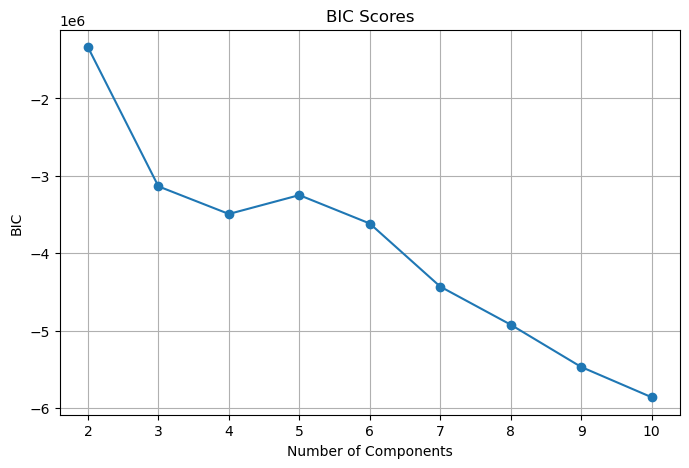

In [100]:
plt.figure(figsize=(8,5))

plt.plot(

    n_components,

    bic_scores,

    marker='o'
)

plt.title(
    "BIC Scores"
)

plt.xlabel(
    "Number of Components"
)

plt.ylabel(
    "BIC"
)

plt.grid(True)

plt.show()

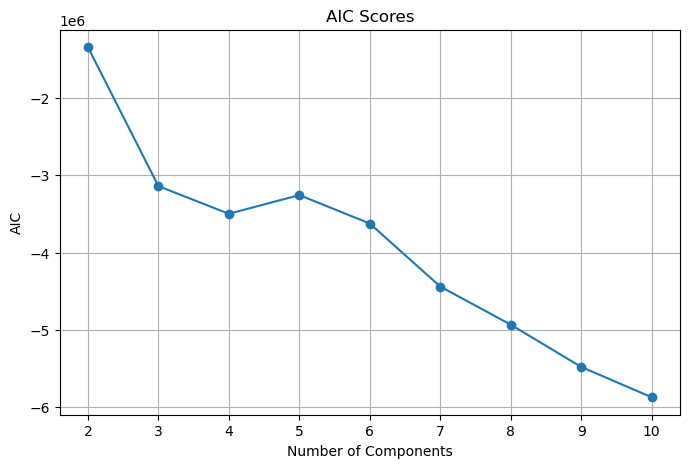

In [101]:
plt.figure(figsize=(8,5))

plt.plot(

    n_components,

    aic_scores,

    marker='o'
)

plt.title(
    "AIC Scores"
)

plt.xlabel(
    "Number of Components"
)

plt.ylabel(
    "AIC"
)

plt.grid(True)

plt.show()

In [102]:
best_n = n_components[np.argmin(bic_scores)]

In [103]:
gmm = GaussianMixture(

    n_components=best_n,

    random_state=42
)

gmm.fit(scaled_features)

GaussianMixture(n_components=10, random_state=42)

In [104]:
rfm_encoded["Cluster"] = gmm.predict(

    scaled_features
)

In [105]:
probabilities = gmm.predict_proba(
    scaled_features
)

In [106]:
prob_df = pd.DataFrame(

    probabilities,

    columns=[

        f"Cluster_Prob_{i}"

        for i in range(best_n)
    ]
)

In [107]:
rfm_final = pd.concat(

    [rfm_encoded, prob_df],

    axis=1
)

In [108]:
rfm_final["Max_Prob"] = probabilities.max(axis=1)

borderline_customers = rfm_final[

    rfm_final["Max_Prob"] < 0.60
]

print(borderline_customers.head())

Empty DataFrame
Columns: [CustomerID, Recency, Frequency, Monetary, Category_Clocks, Category_Furniture & Decor, Category_Garden, Category_Home Decor, Category_Kids, Category_Kitchen, Category_Lighting, Category_Other, Category_Photo & Frames, Category_Seasonal, Category_Stationery, Category_Storage & Bags, Category_Textile, Cluster, Cluster_Prob_0, Cluster_Prob_1, Cluster_Prob_2, Cluster_Prob_3, Cluster_Prob_4, Cluster_Prob_5, Cluster_Prob_6, Cluster_Prob_7, Cluster_Prob_8, Cluster_Prob_9, Max_Prob]
Index: []

[0 rows x 29 columns]


In [109]:
vip_customers = rfm_final[

    (rfm_final["Monetary"] >
     rfm_final["Monetary"].quantile(0.99))

    &

    (rfm_final["Frequency"] >
     rfm_final["Frequency"].quantile(0.95))
]

print(vip_customers.head())

     CustomerID  Recency  Frequency  Monetary  Category_Clocks  \
490     12415.0       25         14  11083.21            False   
492     12415.0       25         22  69882.42            False   
496     12415.0       25         15  23714.39            False   
690     12437.0        2         39   5518.32            False   
929     12471.0        2         75  24524.60            False   

     Category_Furniture & Decor  Category_Garden  Category_Home Decor  \
490                       False            False                False   
492                       False            False                False   
496                       False            False                False   
690                       False            False                False   
929                       False            False                False   

     Category_Kids  Category_Kitchen  ...  Cluster_Prob_1  Cluster_Prob_2  \
490          False              True  ...             0.0             0.0   
492       

In [110]:
cluster_summary = rfm_final.groupby(

    "Cluster"

)[

    ["Recency",
     "Frequency",
     "Monetary"]

].mean()

print(cluster_summary)

            Recency  Frequency    Monetary
Cluster                                   
0        182.155722   2.547842  160.050313
1        215.662059   4.797877  429.826641
2        228.766195   4.409784  636.265643
3        271.945264   2.842251   94.937297
4        243.809180   3.296133  146.296797
5        244.699492   3.056853  167.127812
6        223.334754   4.515235  332.420641
7        255.237515   3.540941  194.866832
8        221.292301   4.913339  568.297616
9        253.819892   3.018817  184.204339


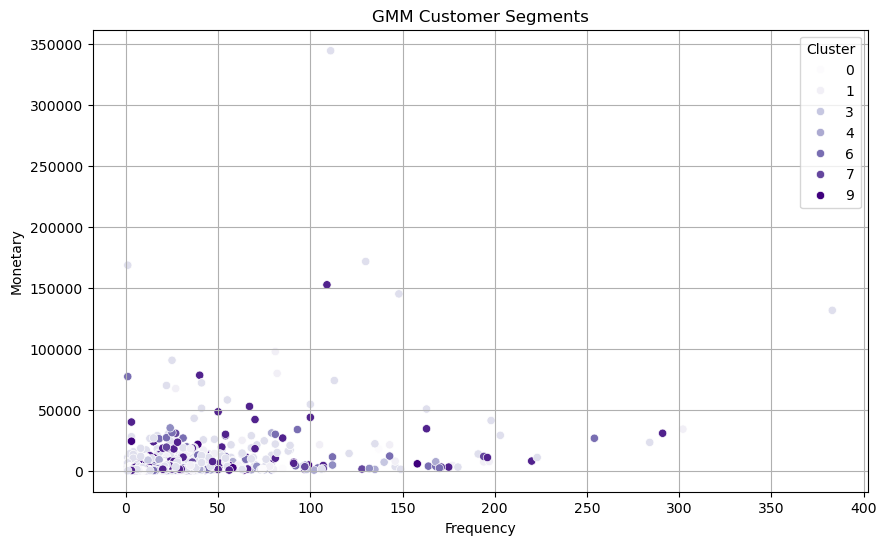

In [112]:
plt.figure(figsize=(10,6))

sns.scatterplot(

    x="Frequency",

    y="Monetary",

    hue="Cluster",

    data=rfm_final,

    palette="Purples"
)

plt.title(
    "GMM Customer Segments"
)

plt.grid(True)

plt.show()                              ##Visualize GMM Clusters##

In [ ]:
##Segment profiling: revenue contribution, churn risk, category affinity, CLV estimate per cluster##

In [113]:
customer_clusters = rfm_final[

    ["CustomerID", "Cluster"]

].drop_duplicates()

In [114]:
data_clustered = pd.merge(

    data,

    customer_clusters,

    on="CustomerID",

    how="left"
)

In [115]:
cluster_revenue = data_clustered.groupby(

    "Cluster"

)["Revenue"].sum()

In [116]:
revenue_percent = (

    cluster_revenue

    / cluster_revenue.sum()

) * 100

In [117]:
revenue_profile = pd.DataFrame({

    "Revenue":

    cluster_revenue,

    "Revenue_Percent":

    revenue_percent
})

print(revenue_profile)

              Revenue  Revenue_Percent
Cluster                               
0        1.362558e+07         9.379597
1        1.628174e+07        11.208051
2        1.727023e+07        11.888506
3        1.386596e+07         9.545069
4        1.426477e+07         9.819603
5        1.063387e+07         7.320158
6        1.602277e+07        11.029778
7        1.424295e+07         9.804583
8        1.636915e+07        11.268224
9        1.269126e+07         8.736431


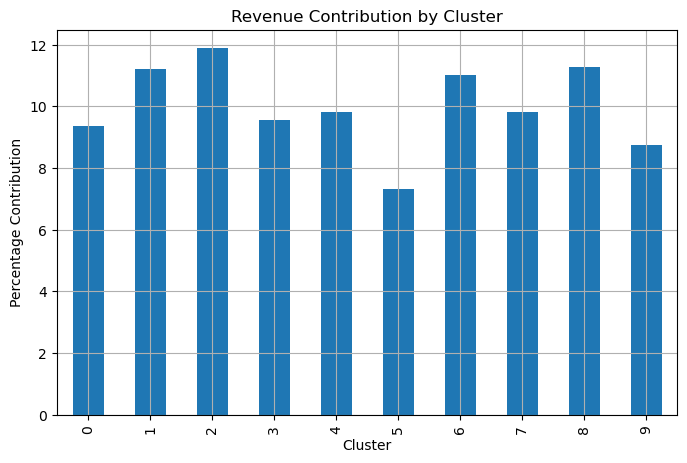

In [118]:
plt.figure(figsize=(8,5))

revenue_percent.plot(

    kind='bar'
)

plt.title(
    "Revenue Contribution by Cluster"
)

plt.ylabel(
    "Percentage Contribution"
)

plt.grid(True)

plt.show()

In [119]:
churn_risk = rfm_final.groupby(

    "Cluster"

)["Recency"].mean()

In [120]:
print(churn_risk)

Cluster
0    182.155722
1    215.662059
2    228.766195
3    271.945264
4    243.809180
5    244.699492
6    223.334754
7    255.237515
8    221.292301
9    253.819892
Name: Recency, dtype: float64


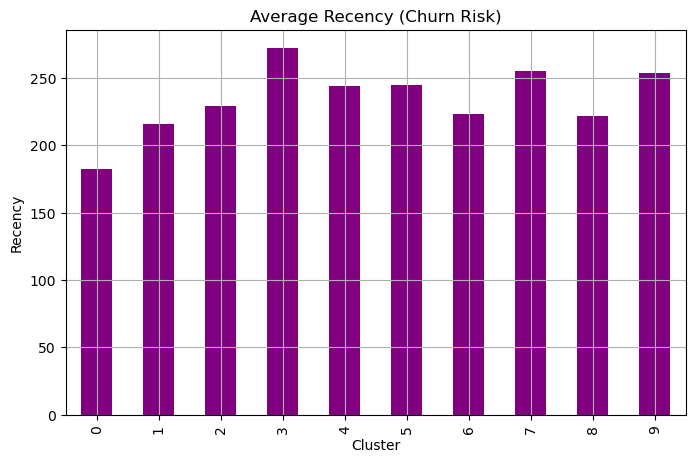

In [121]:
plt.figure(figsize=(8,5))

churn_risk.plot(

    kind='bar',

    color='purple'
)

plt.title(
    "Average Recency (Churn Risk)"
)

plt.ylabel(
    "Recency"
)

plt.grid(True)

plt.show()

In [122]:
category_affinity = data_clustered.groupby(

    ["Cluster", "Category"]

).size()

In [123]:
category_affinity = category_affinity.unstack(
    fill_value=0
)

In [124]:
category_affinity_percent = (

    category_affinity.div(

        category_affinity.sum(axis=1),

        axis=0
    )

) * 100

In [125]:
print(category_affinity_percent)

Category    Clocks  Furniture & Decor    Garden  Home Decor      Kids  \
Cluster                                                                 
0         0.991750           4.301173  1.914210   13.384505  3.340701   
1         0.989415           4.229416  1.954755   13.588428  3.310654   
2         1.003274           4.216780  1.952865   13.312511  3.359785   
3         0.993323           4.262769  2.263486   13.365329  3.362519   
4         0.966905           4.071953  1.914909   12.570207  3.894407   
5         1.031637           4.508485  1.914903   13.958395  3.105343   
6         1.015376           4.254327  1.949966   13.359070  3.300401   
7         1.026928           4.768139  1.971411   13.464151  3.258591   
8         0.998118           4.191071  1.938255   13.155503  3.389061   
9         0.990222           4.196384  1.901838   13.196840  3.336298   

Category   Kitchen  Lighting      Other  Photo & Frames  Seasonal  Stationery  \
Cluster                                   

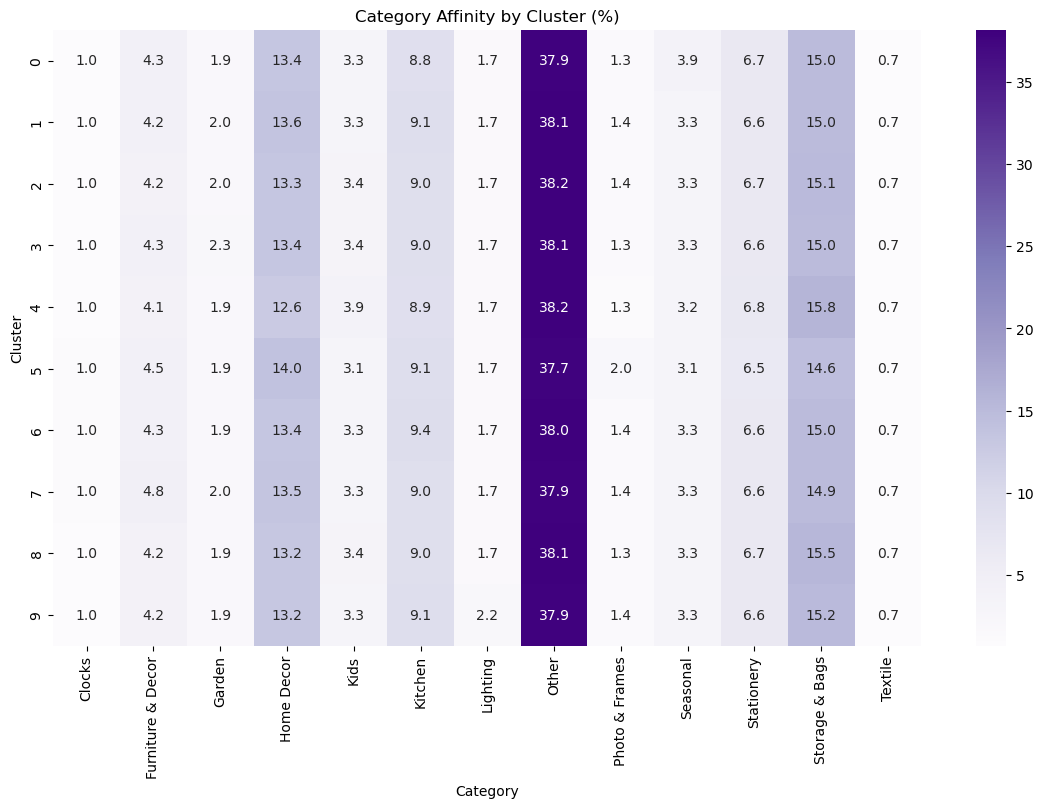

In [126]:
plt.figure(figsize=(14,8))

sns.heatmap(

    category_affinity_percent,

    annot=True,

    cmap="Purples",

    fmt=".1f"
)

plt.title(
    "Category Affinity by Cluster (%)"
)

plt.show()

In [128]:
avg_purchase = rfm_final["Monetary"] / rfm_final["Frequency"]

In [129]:
purchase_frequency = rfm_final["Frequency"]

In [130]:
rfm_final["CLV"] = (

    avg_purchase

    * purchase_frequency

    * 12
)

In [131]:
cluster_clv = rfm_final.groupby(

    "Cluster"

)["CLV"].mean()

In [132]:
print(cluster_clv)

Cluster
0    1920.603752
1    5157.919688
2    7635.187711
3    1139.247565
4    1755.561559
5    2005.533746
6    3989.047697
7    2338.401986
8    6819.571396
9    2210.452074
Name: CLV, dtype: float64


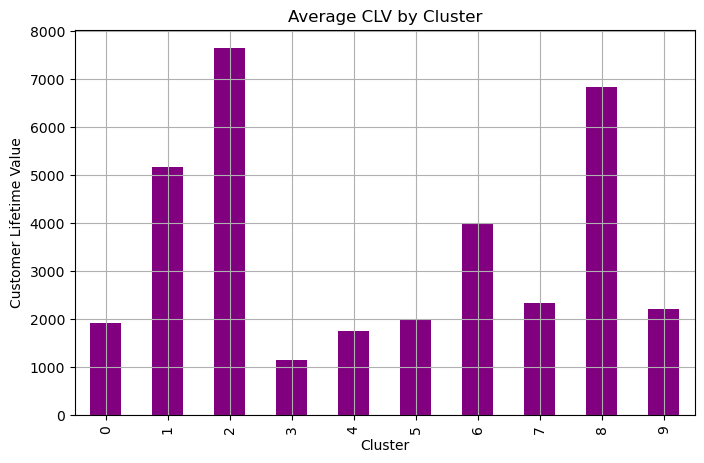

In [133]:
plt.figure(figsize=(8,5))

cluster_clv.plot(

    kind='bar',

    color='purple'
)

plt.title(
    "Average CLV by Cluster"
)

plt.ylabel(
    "Customer Lifetime Value"
)

plt.grid(True)

plt.show()

In [134]:
segment_profile = pd.DataFrame({

    "Revenue_Contribution_%":

    revenue_percent,

    "Avg_Recency":

    churn_risk,

    "Avg_CLV":

    cluster_clv
})

In [135]:
print(segment_profile)

         Revenue_Contribution_%  Avg_Recency      Avg_CLV
Cluster                                                  
0                      9.379597   182.155722  1920.603752
1                     11.208051   215.662059  5157.919688
2                     11.888506   228.766195  7635.187711
3                      9.545069   271.945264  1139.247565
4                      9.819603   243.809180  1755.561559
5                      7.320158   244.699492  2005.533746
6                     11.029778   223.334754  3989.047697
7                      9.804583   255.237515  2338.401986
8                     11.268224   221.292301  6819.571396
9                      8.736431   253.819892  2210.452074


In [ ]:
##CRM export: high-churn-risk segment with SHAP-based retention action codes##


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\sabsm\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\sabsm\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\sabsm\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\sabsm\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\sabsm\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\sabsm\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\sabsm\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\sabsm\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\sabsm\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\sabsm\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\sabsm\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\sabsm\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\sabsm\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\Users\sabsm\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "C:\Users\sabsm\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\sabsm\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found

2.4.4
3.0.2
